In [1]:
import sys
import os
import json
import torch


import numpy as np
import matplotlib.pyplot as plt
import pandas

from matplotlib import rcParams
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage,AnchoredOffsetbox
import glob
from sklearn.metrics import mean_squared_error
from torchmetrics.image import StructuralSimilarityIndexMeasure
import torchvision

from numpy import dot
from numpy.linalg import norm


rcParams['font.family'] = 'Serif'
#rcParams['font.sans-serif'] = ['Times New Roman']
plt.rcParams.update({'font.size': 18})

ssim = StructuralSimilarityIndexMeasure()

from scipy.interpolate import interp1d


Angle 0° - Cosine: 0.4710754660303111, MSE: 0.01960548064228301
Angle 10° - Cosine: 0.16288690721004578, MSE: 0.0009701835469586629
Angle 20° - Cosine: 0.053416580909479816, MSE: 0.014390578464267147


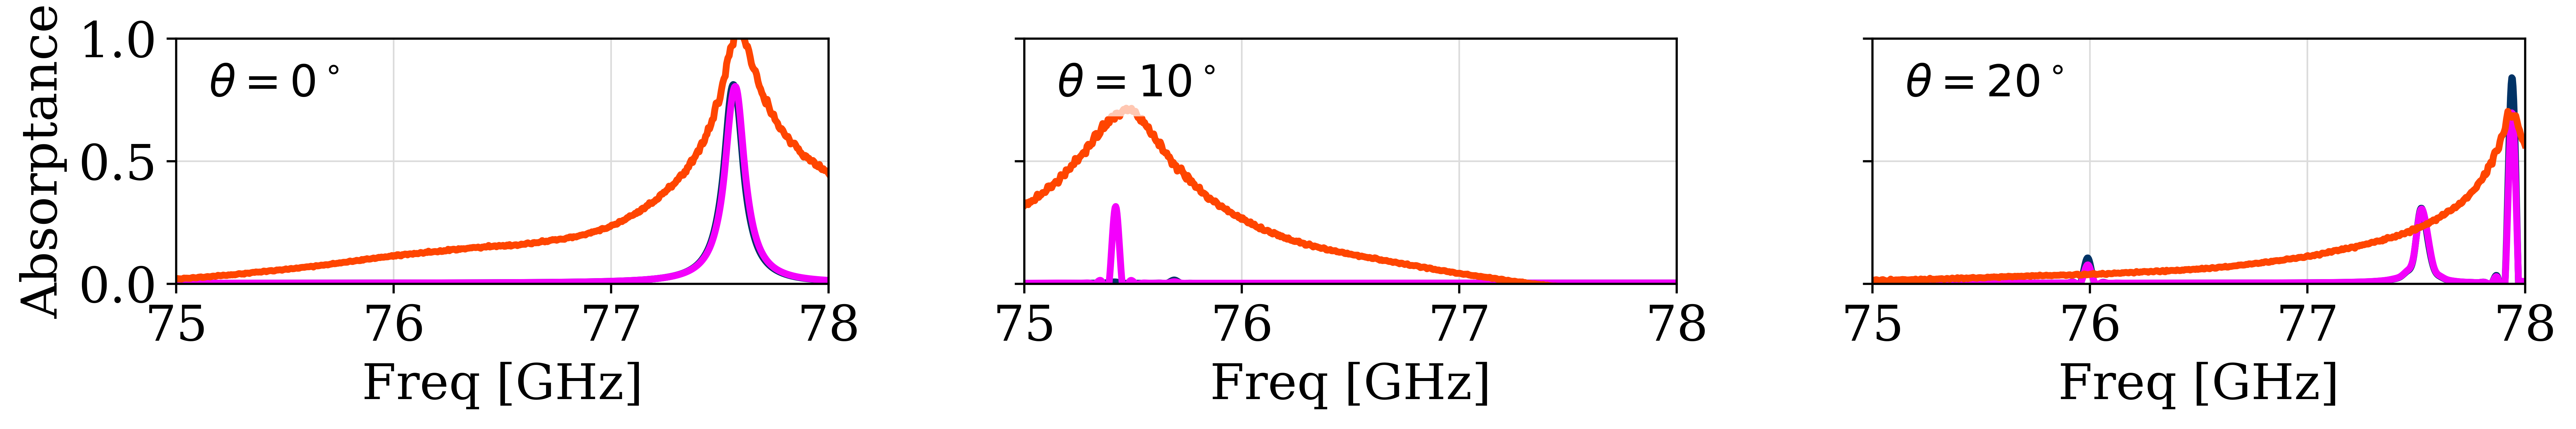

In [2]:
import glob
import pandas
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
from sklearn.metrics import mean_squared_error
from numpy import dot
from numpy.linalg import norm

path="./"

angles = [0, 10, 20]  # Select three angles
line_styles = ['-', '-', '-']  # Adjusted for three angles
blues = ['#003366', '#003366', '#003366']  # Colors for Reference TE
reds = ['#F300FC', '#F300FC', '#F300FC']  # Colors for Generated TM

# Create a figure with three subplots in a row
fig, axs = plt.subplots(1, 3, figsize=(13, 2.3), dpi=600)
csvFileRef = pandas.read_csv(path + '/AbsorptionRef_angle.csv')
csvFileGen = pandas.read_csv(path + '/AbsorptionGen_angle.csv')
csvFileMeasured = pandas.read_csv(path + '/absorption_all_angles.csv')
 
for idx, angle in enumerate(angles):    

    filtered = csvFileRef[csvFileRef['angle [deg]'] == angle]
    filteredGen = csvFileGen[csvFileGen['angle [deg]'] == angle]
    
    
    minFreq = int(list(filtered["Freq [GHz]"])[0])
    maxFreq = int(list(filtered["Freq [GHz]"])[-1])

    
    #Measured
    Freq_mes = csvFileMeasured["Frequency_GHz"]
    Abs_mes =  csvFileMeasured.iloc[:, idx+1]
    
    
    # Reference TE
    Freq = filtered["Freq [GHz]"]

    X_Y_Spline = interp1d(filtered["Freq [GHz]"], filtered["AbsorbanceTE []"], kind='cubic')
    X_ = np.linspace(filtered["Freq [GHz]"].min(), filtered["Freq [GHz]"].max(), 1000)
    Y_ = X_Y_Spline(X_)

    # Generated TM
    X_Y_Spline = interp1d(Freq, filteredGen["AbsorbanceTE []"], kind='cubic')
    X_gen = np.linspace(Freq.min(), Freq.max(), 1000)
    Y_gen = X_Y_Spline(X_)

    ax = axs[idx]
    
    
    ax.plot(X_, Y_, linestyle=line_styles[idx], label='Reference TE', linewidth=2.5, color=blues[idx])
    ax.plot(X_gen, Y_gen, linestyle=line_styles[idx], label='Generated TE', linewidth=2.5, color=reds[idx])
    ax.plot(Freq_mes, Abs_mes, linestyle=line_styles[idx], label='Measured TE', linewidth=2.5, color="orangered")

    ax.set_ylim(0, 1.0)
    ax.set_xlim(minFreq, maxFreq)
    ax.set_xticks([75, 76, 77, 78])

    # Set labels
    if idx == 0:  # Only leftmost plot
        ax.set_ylabel("Absorptance")
    else:
        ax.set_yticklabels([])

    ax.set_xlabel("Freq [GHz]")

    # Add angle annotation
    ax.text(0.05, 0.90, rf'$\theta={angle}^\circ$', transform=ax.transAxes, fontsize=16,
            verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    ax.grid(which='major', axis='both', linestyle='-', color='#DCDCDC', linewidth=0.6)

    # Calculate metrics
    abs_ref = np.roll(filtered["AbsorbanceTE []"], 0) 
    abs_gen = np.roll(filteredGen["AbsorbanceTE []"], -4) 

    mse = mean_squared_error(abs_ref, abs_gen )
    cos_sim = dot(abs_ref, abs_gen) / (
                norm(abs_ref) * norm(abs_gen))
    print(f"Angle {angle}° - Cosine: {cos_sim}, MSE: {mse}")

    # Add a single legend for the entire figure
    #fig.legend(['Reference TE', 'Generated TM'], loc='upper center', ncol=2, fontsize=12)

plt.tight_layout(pad=0.3)
plt.subplots_adjust(wspace=0.3, top=0.85)  # Adjust spacing and make room for legend

# Save the figure
plt.savefig(path + '/results_three_angles_pol1.png', transparent=False, bbox_inches='tight')
plt.show()